# UCI Adult - Analyzing Income Factors
**EPITA – MSc Artificial Intelligence Systems (AIS)**  
**Spark & Python for Big Data AIS S2 F25**

**Students:**
- TRUONG Kim Tan
- LE Linh Long
- Farouk RAHAL

---

## Step 0: Imports and Data Loading

### 0.1. Imports

In [33]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, udf
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

import warnings
warnings.filterwarnings('ignore')

### 0.2. Spark Session Initialization

In [34]:
spark = SparkSession.builder \
    .appName("AdultCensusIncome_Spark") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
spark.sparkContext.getConf().getAll()
spark.sparkContext.setLogLevel("ERROR")

Spark version: 4.1.1


### 0.3. Data Loading with Spark

In [35]:
csv_file = glob.glob(f"adult.csv", recursive=True)[0]

# Define schema
schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("workclass", StringType(), True),
    StructField("fnlwgt", IntegerType(), True),
    StructField("education", StringType(), True),
    StructField("education_num", IntegerType(), True),
    StructField("marital_status", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("relationship", StringType(), True),
    StructField("race", StringType(), True),
    StructField("sex", StringType(), True),
    StructField("capital_gain", IntegerType(), True),
    StructField("capital_loss", IntegerType(), True),
    StructField("hours_per_week", IntegerType(), True),
    StructField("native_country", StringType(), True),
    StructField("income", StringType(), True)
])

df = spark.read.csv(csv_file, schema=schema, header=True,
                    nullValue="?",
                    ignoreLeadingWhiteSpace=True,
                    ignoreTrailingWhiteSpace=True)

df.cache()

print("Schema:")
df.printSchema()
print(f"Total records: {df.count():,}")
df.show(5, truncate=False)

Schema:
root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)

Total records: 32,561
+---+---------+------+------------+-------------+--------------+-----------------+-------------+-----+------+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education   |education_num|marital_status|occupation       |relationship |race |sex   |capital_gain|capital_loss|hours_per_week|native_country

### 0.4. Data Exploration

#### a. Dataset Overview

In [36]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: integer (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: integer (nullable = true)
 |-- capital_loss: integer (nullable = true)
 |-- hours_per_week: integer (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



#### b. Missing Values

In [37]:
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|age|workclass|fnlwgt|education|education_num|marital_status|occupation|relationship|race|sex|capital_gain|capital_loss|hours_per_week|native_country|income|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+
|  0|     1836|     0|        0|            0|             0|      1843|           0|   0|  0|           0|           0|             0|           583|     0|
+---+---------+------+---------+-------------+--------------+----------+------------+----+---+------------+------------+--------------+--------------+------+



#### c. Data Distribution

In [38]:
df.groupBy("income").count() \
  .withColumn("percentage", F.col("count") / df.count() * 100) \
  .show()

+------+-----+------------------+
|income|count|        percentage|
+------+-----+------------------+
| <=50K|24720| 75.91904425539757|
|  >50K| 7841|24.080955744602438|
+------+-----+------------------+



#### d. Correlation Matrix

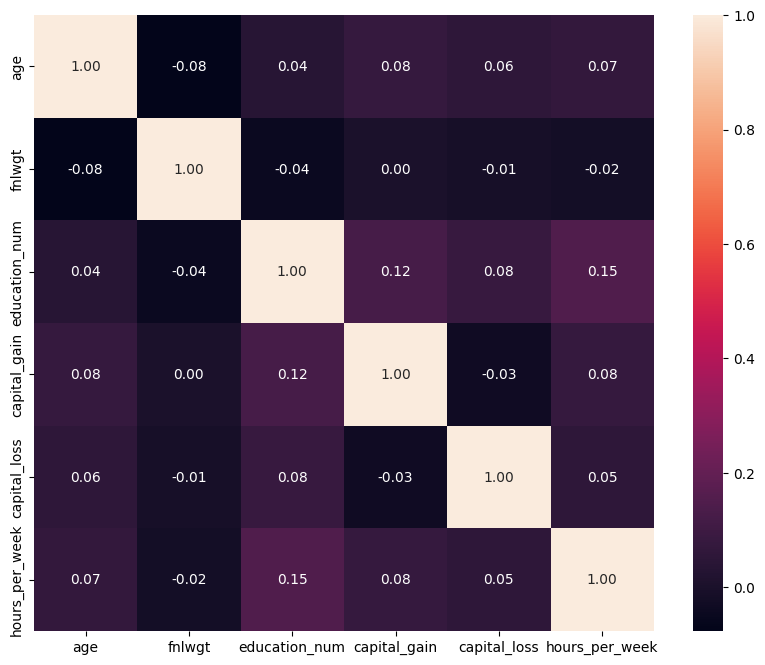

In [39]:
numeric_cols = [c for c, t in df.dtypes if t in ["int", "double"]]
pdf = df.select(numeric_cols).toPandas()

plt.figure(figsize=(10,8))
sns.heatmap(pdf.corr(), annot=True, fmt=".2f")
plt.show()

## Step 1: Data Cleaning and Preparation

### 1.1. Handling Missing Values

#### a. Creating $Unknown$ category for missing values

In [40]:
df_imputed = df.withColumn(
    'workclass',
    F.when(F.isnull('workclass'), "Unknown").otherwise(F.col('workclass'))
).withColumn(
    'occupation',
    F.when(F.isnull('occupation'), "Unknown").otherwise(F.col('occupation'))
).withColumn(
    'native_country',
    F.when(F.isnull('native_country'), "Unknown").otherwise(F.col('native_country'))
)

#### b. Verification

In [41]:
print(f"Workclass nulls remaining: {df_imputed.filter(F.isnull('workclass')).count():,}")
print(f"Occupation nulls remaining: {df_imputed.filter(F.isnull('occupation')).count():,}")
print(f"Native country nulls remaining: {df_imputed.filter(F.isnull('native_country')).count():,}")

df = df_imputed

Workclass nulls remaining: 0
Occupation nulls remaining: 0
Native country nulls remaining: 0


### 1.2. Redundancy Check

#### a. Unique combinations of `education` and `education_num`

In [42]:
education_mapping = df.groupBy("education", "education_num").count().orderBy("education_num")
education_mapping.show(truncate=False)

print(f"Total unique education levels: {df.select('education').distinct().count()}")
print(f"Total unique education_num values: {df.select('education_num').distinct().count()}")

+------------+-------------+-----+
|education   |education_num|count|
+------------+-------------+-----+
|Preschool   |1            |51   |
|1st-4th     |2            |168  |
|5th-6th     |3            |333  |
|7th-8th     |4            |646  |
|9th         |5            |514  |
|10th        |6            |933  |
|11th        |7            |1175 |
|12th        |8            |433  |
|HS-grad     |9            |10501|
|Some-college|10           |7291 |
|Assoc-voc   |11           |1382 |
|Assoc-acdm  |12           |1067 |
|Bachelors   |13           |5355 |
|Masters     |14           |1723 |
|Prof-school |15           |576  |
|Doctorate   |16           |413  |
+------------+-------------+-----+

Total unique education levels: 16
Total unique education_num values: 16


#### b. One-to-one Mapping Check

In [43]:
mapping_count = education_mapping.count()
unique_education = df.select("education").distinct().count()
unique_education_num = df.select("education_num").distinct().count()

print(f"Number of (education, education_num) pairs: {mapping_count}")

if mapping_count == unique_education == unique_education_num:
    print("Every education label maps to exactly one education_num")

    # Show the mapping for reference
    print("Education Mapping Reference: ")
    mapping_df = education_mapping.select("education", "education_num").orderBy("education_num")
    mapping_df.show(truncate=False)

Number of (education, education_num) pairs: 16
Every education label maps to exactly one education_num
Education Mapping Reference: 
+------------+-------------+
|education   |education_num|
+------------+-------------+
|Preschool   |1            |
|1st-4th     |2            |
|5th-6th     |3            |
|7th-8th     |4            |
|9th         |5            |
|10th        |6            |
|11th        |7            |
|12th        |8            |
|HS-grad     |9            |
|Some-college|10           |
|Assoc-voc   |11           |
|Assoc-acdm  |12           |
|Bachelors   |13           |
|Masters     |14           |
|Prof-school |15           |
|Doctorate   |16           |
+------------+-------------+



From the One-to-one mapping check, we can see that:
- Every education label maps to exactly 1 education_num
- And every education_num maps to exactly 1 education label
So the relationship is 1-to-1. Therefore, we'll drop the `education` column and keep the `education_num` because we want to work with numerical features for machine learning.

#### c. Redundancy Drop

In [44]:
df = df.drop("education")

### 1.3. Categorical Columns Cleaning

#### a. Categorical Columns

In [45]:
categorical_cols = [field.name for field in df.schema.fields if str(field.dataType) == "StringType()"]
print(f"Categorical columns: {categorical_cols}")


Categorical columns: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


#### b. Categorical Columns Cleaning

In [46]:
whitespace_cleaned = []
for col_name in categorical_cols:
    print(f"Checking column: '{col_name}'")

    # We will check for leading/trailing whitespace using rlike (regex)
    has_whitespace = df.filter(F.col(col_name).rlike("^\\s+|\\s+$")).count()

    print(f"  Records with surrounding whitespace: {has_whitespace}")

    if has_whitespace > 0:
        print(f"  Cleaning whitespace in '{col_name}'")
        df = df.withColumn(col_name, F.trim(F.col(col_name)))
        whitespace_cleaned.append(col_name)
    else:
        print(f"  No surrounding whitespace found in '{col_name}'")

print("-"*40)
print(f"Whitespace Cleaning Summary")
print("-"*40)
if whitespace_cleaned:
    print(f"Cleaned columns: {whitespace_cleaned}")
else:
    print("No whitespace issues found in any columns")

Checking column: 'workclass'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'workclass'
Checking column: 'marital_status'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'marital_status'
Checking column: 'occupation'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'occupation'
Checking column: 'relationship'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'relationship'
Checking column: 'race'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'race'
Checking column: 'sex'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'sex'
Checking column: 'native_country'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'native_country'
Checking column: 'income'
  Records with surrounding whitespace: 0
  No surrounding whitespace found in 'income'
----------------------------------------
Whitesp

## Step 2 : Feature Transformation and Engineering

### 2.1. Target Transformation

In [47]:
df = df.withColumn(
    "label",
    F.when(F.col("income") == ">50K", 1).otherwise(0)
).drop("income") # convert the income column into a binary integer label

df.groupBy("label").count().show() 

+-----+-----+
|label|count|
+-----+-----+
|    1| 7841|
|    0|24720|
+-----+-----+



### 2.2. Analyzing Capital Gains/Losse

In [48]:
df = df.withColumn("net_capital", F.col("capital_gain") - F.col("capital_loss")) #create a new feature representing the capital income
df.groupBy("label") \
  .agg(F.avg("net_capital").alias("avg_net_capital"),
       F.count("*").alias("count")) \
  .orderBy("label") \
  .show() #  visualize the average net capital between classes
df = df.drop("capital_gain", "capital_loss")

+-----+------------------+-----+
|label|   avg_net_capital|count|
+-----+------------------+-----+
|    0| 95.60954692556635|24720|
|    1|3811.1409259023085| 7841|
+-----+------------------+-----+



### 2.3. Grouping Countries

In [49]:
df.groupBy("native_country").count().orderBy(F.desc("count")).show(truncate=False)

+------------------+-----+
|native_country    |count|
+------------------+-----+
|United-States     |29170|
|Mexico            |643  |
|Unknown           |583  |
|Philippines       |198  |
|Germany           |137  |
|Canada            |121  |
|Puerto-Rico       |114  |
|El-Salvador       |106  |
|India             |100  |
|Cuba              |95   |
|England           |90   |
|Jamaica           |81   |
|South             |80   |
|China             |75   |
|Italy             |73   |
|Dominican-Republic|70   |
|Vietnam           |67   |
|Guatemala         |64   |
|Japan             |62   |
|Poland            |60   |
+------------------+-----+
only showing top 20 rows


In [ ]:
df = df.withColumn( # change every other country other than USA to be other, to avoid curse of dimensionality when applying One Hot Encoder
    "native_country",
    F.when(F.col("native_country") == "United-States", "United-States")
     .otherwise("Other")
)

df.groupBy("native_country").count().orderBy(F.desc("count")).show()

+--------------+-----+
|native_country|count|
+--------------+-----+
| United-States|29170|
|         Other| 3391|
+--------------+-----+



### 2.4. Export Processed Data

In [51]:
df_pandas = df.toPandas()
df_pandas.to_csv("processed.csv")

## Step 3: Unsupervised Learning

### 3.1. Train Test Split

Spliting the data in 80-20 ratio, and add a seed for reproducibility

In [52]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=36)
print("Train count:", train_df.count())
print("Test count:", test_df.count())

Train count: 26167
Test count: 6394


### 3.2. Pipeline Building

We extract the numerical features, scaling the data to create Standard Scaler, to create a Pipeline for Unsupervised Learning

In [53]:
numeric_types = ['int', 'double', 'float']
num_cols = [col for col, dtype in df.dtypes if dtype in numeric_types and col != 'label']

assembler = VectorAssembler(inputCols=num_cols, outputCol="assembled_features")
scaler = StandardScaler(inputCol="assembled_features", outputCol="features", withStd=True, withMean=True)
pca = PCA(k=2, inputCol="features", outputCol="pca_features")

pipeline_ul = Pipeline(stages=[assembler, scaler, pca])
pipeline_ul_model = pipeline_ul.fit(train_df)
train_result_ul = pipeline_ul_model.transform(train_df)

Setting k=2 for PCA to check it's seperation, and to see it's explained variance

Total Variance Captured: 46.36%


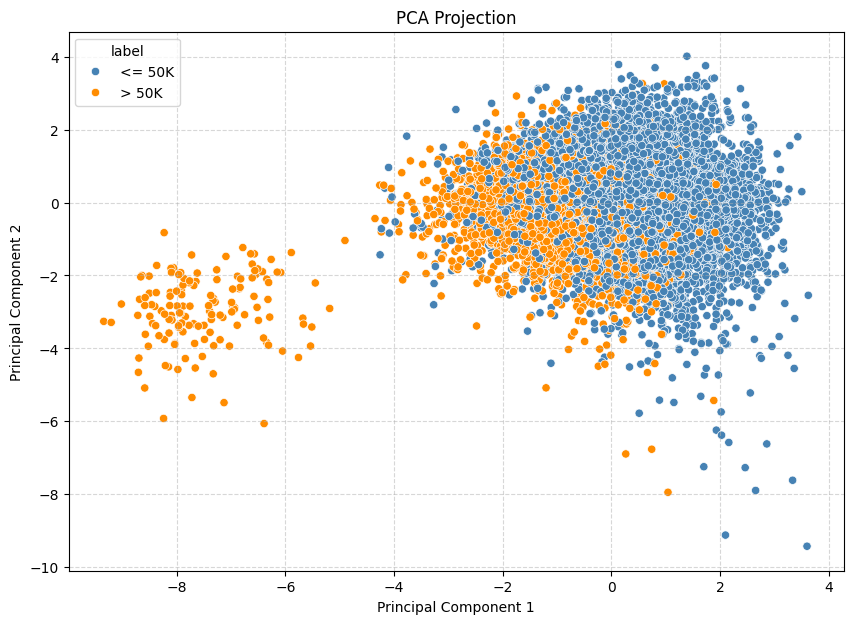

In [54]:
def extract_pca_fn(vec, idx):
    return float(vec[idx])

extract_pca_udf = udf(extract_pca_fn)

plot_df = train_result_ul.select(
    vector_to_array("pca_features").alias("pca_array"), 
    "label"
).select(
    col("pca_array")[0].alias("PC1"),
    col("pca_array")[1].alias("PC2"),
    "label"
).toPandas()

pca_model = pipeline_ul_model.stages[2]
variance_ratios = pca_model.explainedVariance.toArray()
total_var = sum(variance_ratios) * 100
print(f"Total Variance Captured: {total_var:.2f}%")

label_map = {0: '<= 50K', 1: '> 50K'}
plot_df['label'] = plot_df['label'].map(label_map)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="label", palette={'<= 50K': 'steelblue', '> 50K': 'darkorange'})
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

As observed from the graph, there is a clear separation showed by the isolated cluster of Label 1 whose color is orange on the far left, but a significant overlap zone exists where the two classes are heavily merged. This shows that the PCA with k=2 cannot help seperate the data efficiently and correctly into our 2 desired label groups.

## Step 4: Data Visualization

## Step 5: Modeling and Prediction

### 5.1. Pipeline Building

We apply One-Hot Encoder for categorical features, and then we scaled the data using Standard Scaler, to generate a Pipeline for Supervised Learning

In [55]:
cat_cols = ["workclass",  "marital_status", "occupation","relationship", "race", "sex", "native_country"]
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_indexed",
        handleInvalid="keep"
    )
    for col in cat_cols
]

encoders = [
    OneHotEncoder(
        inputCol=col + "_indexed",
        outputCol=col + "_ohe"
    )
    for col in cat_cols
]

assembler = VectorAssembler(
    inputCols=num_cols + [col + "_ohe" for col in cat_cols],
    outputCol="assembled_features"
)

scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features",
    withStd=True,
    withMean=True
)

pipeline_sl = Pipeline(stages=indexers + encoders + [assembler, scaler])

pipeline_sl_model = pipeline_sl.fit(train_df) # we dont fit on test set to avoid data leakage
train_result = pipeline_sl_model.transform(train_df)
test_result = pipeline_sl_model.transform(test_df)

train_result = train_result.select("features", "label")
test_result = test_result.select("features", "label")

### 5.2. Logistic Regression

#### a. Model Hyperparameter Tuning

In [56]:
model_lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

param_grid_lr = ( # apply hyperparameter tuning to find the best parameter for this dataset
    ParamGridBuilder()
    .addGrid(model_lr.regParam, [0.01, 0.1, 0.5])
    .addGrid(model_lr.elasticNetParam, [0.0, 0.5, 1.0])
    .addGrid(model_lr.maxIter, [50, 100])
    .build()
)

evaluator_auc_lr = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

cv_lr = CrossValidator(
    estimator=model_lr,  
    estimatorParamMaps=param_grid_lr,  # grid of hyperparameter combinations to evaluate
    evaluator=evaluator_auc_lr,  
    numFolds=3,  # perform 3 fold cross validation to reduce variance in performance estimates
    parallelism=2,  # run 2 models in parallel to speed up training
    seed=36  # reproducibility purpose
)

cv_model_lr = cv_lr.fit(train_result)
best_model_lr = cv_model_lr.bestModel 

print("===== Cross Validation Results =====")
for metric, params in zip(cv_model_lr.avgMetrics, param_grid_lr):
    print(
        f"AUC: {metric:.6f} | "
        f"regParam={params[model_lr.regParam]}, "
        f"elasticNetParam={params[model_lr.elasticNetParam]}, "
        f"maxIter={params[model_lr.maxIter]}"
    )
print()
print("===== Best Hyperparameters =====")
print("regParam        :", best_model_lr._java_obj.getRegParam())
print("elasticNetParam :", best_model_lr._java_obj.getElasticNetParam())
print("maxIter         :", best_model_lr._java_obj.getMaxIter())

===== Cross Validation Results =====
AUC: 0.897757 | regParam=0.01, elasticNetParam=0.0, maxIter=50
AUC: 0.897757 | regParam=0.01, elasticNetParam=0.0, maxIter=100
AUC: 0.896508 | regParam=0.01, elasticNetParam=0.5, maxIter=50
AUC: 0.896508 | regParam=0.01, elasticNetParam=0.5, maxIter=100
AUC: 0.892858 | regParam=0.01, elasticNetParam=1.0, maxIter=50
AUC: 0.892858 | regParam=0.01, elasticNetParam=1.0, maxIter=100
AUC: 0.889873 | regParam=0.1, elasticNetParam=0.0, maxIter=50
AUC: 0.889873 | regParam=0.1, elasticNetParam=0.0, maxIter=100
AUC: 0.869696 | regParam=0.1, elasticNetParam=0.5, maxIter=50
AUC: 0.869696 | regParam=0.1, elasticNetParam=0.5, maxIter=100
AUC: 0.850311 | regParam=0.1, elasticNetParam=1.0, maxIter=50
AUC: 0.850311 | regParam=0.1, elasticNetParam=1.0, maxIter=100
AUC: 0.881112 | regParam=0.5, elasticNetParam=0.0, maxIter=50
AUC: 0.881112 | regParam=0.5, elasticNetParam=0.0, maxIter=100
AUC: 0.500000 | regParam=0.5, elasticNetParam=0.5, maxIter=50
AUC: 0.500000 | regP

#### b. Model Evaluation

In [57]:
test_predictions_lr = best_model_lr.transform(test_result)
test_auc_lr = evaluator_auc_lr.evaluate(test_predictions_lr)

evaluator_accuracy_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall_lr = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy_lr = evaluator_accuracy_lr.evaluate(test_predictions_lr)
f1_lr = evaluator_f1_lr.evaluate(test_predictions_lr)
precision_lr = evaluator_precision_lr.evaluate(test_predictions_lr)
recall_lr = evaluator_recall_lr.evaluate(test_predictions_lr)

print("===== Logistic Regression Test Metrics =====")
print(f"AUC       : {test_auc_lr:.4f}")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print()
print("===== Confusion Matrix =====")
test_predictions_lr.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

===== Logistic Regression Test Metrics =====
AUC       : 0.9009
Accuracy  : 0.8474
Precision : 0.8401
Recall    : 0.8474
F1 Score  : 0.8409

===== Confusion Matrix =====
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 4529|
|    0|       1.0|  327|
|    1|       0.0|  649|
|    1|       1.0|  889|
+-----+----------+-----+



### 5.3. Random Forest

#### a. Model Hyperparameter Tuning

In [58]:
model_rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=36 # reproducibility purpose
)

param_grid_rf = ( # same thing as Logistic Regression
    ParamGridBuilder()
    .addGrid(model_rf.numTrees, [25, 50])
    .addGrid(model_rf.maxDepth, [5, 10])
    .addGrid(model_rf.maxBins, [32, 64])
    .build()
)

evaluator_auc_rf = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

cv_rf = CrossValidator(
    estimator=model_rf,
    estimatorParamMaps=param_grid_rf,
    evaluator=evaluator_auc_rf,
    numFolds=3,
    parallelism=2,
    seed=36
)

cv_model_rf = cv_rf.fit(train_result)
best_model_rf = cv_model_rf.bestModel

print("===== Cross Validation Results =====")
for metric, params in zip(cv_model_rf.avgMetrics, param_grid_rf):
    print(
        f"AUC: {metric:.6f} | "
        f"numTrees={params[model_rf.numTrees]}, "
        f"maxDepth={params[model_rf.maxDepth]}, "
        f"maxBins={params[model_rf.maxBins]}"
    )
print()
print("===== Best Hyperparameters =====")
print("numTrees :", best_model_rf.getNumTrees)
print("maxDepth :", best_model_rf.getOrDefault("maxDepth"))
print("maxBins  :", best_model_rf.getOrDefault("maxBins"))

===== Cross Validation Results =====
AUC: 0.891393 | numTrees=25, maxDepth=5, maxBins=32
AUC: 0.895476 | numTrees=25, maxDepth=5, maxBins=64
AUC: 0.904555 | numTrees=25, maxDepth=10, maxBins=32
AUC: 0.908286 | numTrees=25, maxDepth=10, maxBins=64
AUC: 0.892048 | numTrees=50, maxDepth=5, maxBins=32
AUC: 0.895340 | numTrees=50, maxDepth=5, maxBins=64
AUC: 0.905637 | numTrees=50, maxDepth=10, maxBins=32
AUC: 0.909239 | numTrees=50, maxDepth=10, maxBins=64

===== Best Hyperparameters =====
numTrees : 50
maxDepth : 10
maxBins  : 64


#### b. Model Evaluation

In [59]:
test_predictions_rf = best_model_rf.transform(test_result)
test_auc_rf = evaluator_auc_rf.evaluate(test_predictions_rf)

evaluator_accuracy_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_precision_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

evaluator_recall_rf = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

accuracy_rf = evaluator_accuracy_rf.evaluate(test_predictions_rf)
f1_rf = evaluator_f1_rf.evaluate(test_predictions_rf)
precision_rf = evaluator_precision_rf.evaluate(test_predictions_rf)
recall_rf = evaluator_recall_rf.evaluate(test_predictions_rf)

print("===== Random Forest Test Metrics =====")
print(f"AUC       : {test_auc_rf:.4f}")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print()
print("===== Confusion Matrix =====")
test_predictions_rf.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction") \
    .show()

===== Random Forest Test Metrics =====
AUC       : 0.9135
Accuracy  : 0.8583
Precision : 0.8536
Recall    : 0.8583
F1 Score  : 0.8476

===== Confusion Matrix =====
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 4661|
|    0|       1.0|  195|
|    1|       0.0|  711|
|    1|       1.0|  827|
+-----+----------+-----+



#### c. Feature Importance

In [60]:
importances = best_model_rf.featureImportances.toArray() # extract feature importance score out of RF model

temp_df = pipeline_sl_model.transform(train_df.limit(1)) # we only need 1 row because we're extracting schema information, not data
meta = temp_df.schema["assembled_features"].metadata
feature_names = []

attrs = meta["ml_attr"]["attrs"] # Spark stores feature details under ml_attr -> attrs
for attr_type in ["numeric", "binary", "nominal"]: # loop through possible attribute types and collect
    if attr_type in attrs:
        for attr in attrs[attr_type]:
            feature_names.append((attr["idx"], attr["name"]))
feature_names.sort(key=lambda x: x[0])
feature_names = [x[1] for x in feature_names] # keep only the feature names in correct order

importance_df = pd.DataFrame({ # use Pandas for easy dataframe usage
    'Feature': feature_names,
    'Importance': importances
})

top_5_features = importance_df.sort_values(by='Importance', ascending=False).head()
print("===== Top 5 Most Important Features =====")
print(top_5_features.to_string(index=False))

===== Top 5 Most Important Features =====
                              Feature  Importance
                          net_capital    0.227796
marital_status_ohe_Married-civ-spouse    0.155221
                        education_num    0.150344
             relationship_ohe_Husband    0.095283
                                  age    0.060506


### 5.4. Model Comparision

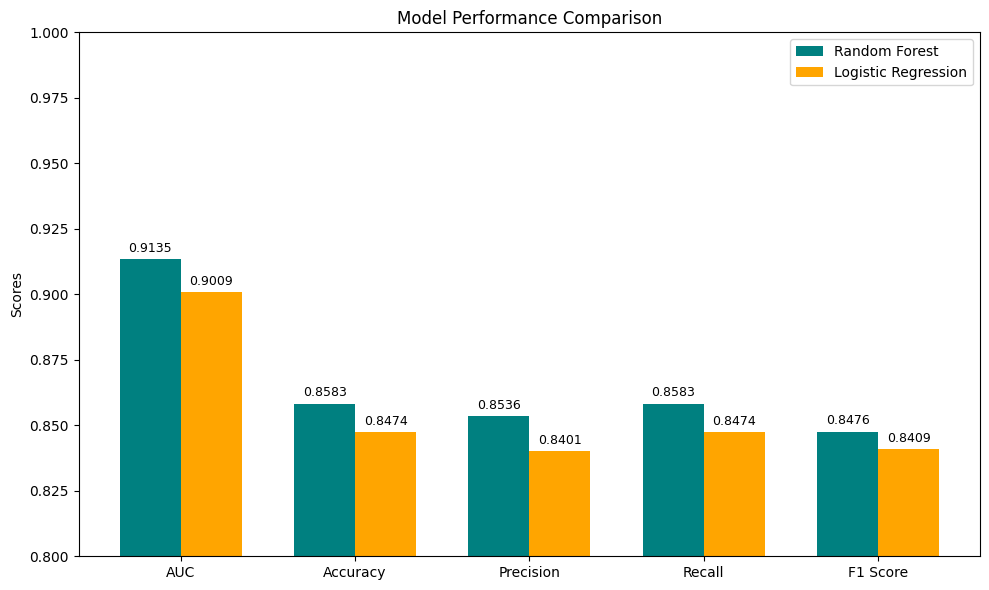

In [61]:
metrics_labels = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

rf_values = [test_auc_rf, accuracy_rf, precision_rf, recall_rf, f1_rf]
lr_values = [test_auc_lr, accuracy_lr, precision_lr, recall_lr, f1_lr]

x = np.arange(len(metrics_labels))  
width = 0.35 

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rf_values, width, label='Random Forest', color='teal')
rects2 = ax.bar(x + width/2, lr_values, width, label='Logistic Regression', color='orange')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.set_ylim(0.8, 1.0) 

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

As observed from the graph, Random Forest outperforms Linear Regression in all metrics. For that reason, Random Forest is a better algorithm to classify high income people in this dataset.

## Step 6: Stop Session

In [62]:
spark.stop()